# Exploratory Data Analysis (EDA)

Notebook ini menganalisis data sebelum pemodelan untuk menjawab pertanyaan berikut:
1. Apakah data lengkap dan bersih?
2. Bagaimana pola pergerakan kurs USD/IDR dan distribusi target NAIK/TURUN?
3. Bagaimana karakteristik teks berita dan seberapa relevan beritanya terhadap kurs?
4. Apakah fitur berita menunjukkan hubungan dengan arah kurs hari berikutnya?

Data yang digunakan adalah `data/processed/aligned_dataset.csv` serta hasil pembagian data
dan fitur NLP. 

## 1. Persiapan Library

In [13]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
DATA = Path("../data") if Path("../data").exists() else Path("data")  # berjalan dari folder notebook atau folder utama repo

## 2. Pemuatan Data dan Pemeriksaan Rentang Tanggal
`aligned_dataset.csv` berisi kurs JISDOR harian beserta gabungan berita per hari.
Data diurutkan berdasarkan tanggal, kemudian diperiksa rentang waktu dan jumlah harinya.

In [14]:
df = pd.read_csv(DATA / "processed" / "aligned_dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by="date").reset_index(drop=True)

# Memeriksa rentang tanggal dan hari yang tidak tercatat
date_range = pd.date_range(start=df["date"].min(), end=df["date"].max())
missing_calendar_days = date_range.difference(df["date"])

print(f"Rentang tanggal          : {df['date'].min().date()} s.d. {df['date'].max().date()}")
print(f"Jumlah hari perdagangan  : {len(df)}")
print(f"Jumlah hari kalender     : {len(date_range)}")
print(f"Hari tidak tercatat      : {len(missing_calendar_days)} hari (akhir pekan dan hari libur)")

Rentang tanggal          : 2021-09-01 s.d. 2026-09-01
Jumlah hari perdagangan  : 1202
Jumlah hari kalender     : 1827
Hari tidak tercatat      : 625 hari (akhir pekan dan hari libur)


## 3. Pemeriksaan Missing Value dan Tanggal Ganda

In [15]:
print("Jumlah nilai kosong per kolom:")
print(df.isnull().sum())

dup_dates = df["date"].duplicated().sum()
print(f"\nTanggal ganda: {dup_dates}")

empty_days = df[df["judul_gabungan"].isna() | (df["judul_gabungan"] == "")]
print(f"Hari tanpa berita: {len(empty_days)} (jumlah_berita = {empty_days['jumlah_berita'].unique()})")

Jumlah nilai kosong per kolom:
date                        0
usd_idr                     0
jumlah_berita               0
judul_gabungan             17
lead_paragraph_gabungan    17
konten_gabungan            17
dtype: int64

Tanggal ganda: 0
Hari tanpa berita: 17 (jumlah_berita = [0])


Tidak terdapat tanggal ganda. Kolom teks kosong hanya terjadi pada 17 hari yang memang tidak memiliki berita,
sehingga bukan merupakan kesalahan data.

## 4. Pergerakan Kurs USD/IDR
Data yang digunakan pada bagian 4 sampai 6 adalah hasil pembagian train, validation, dan test.

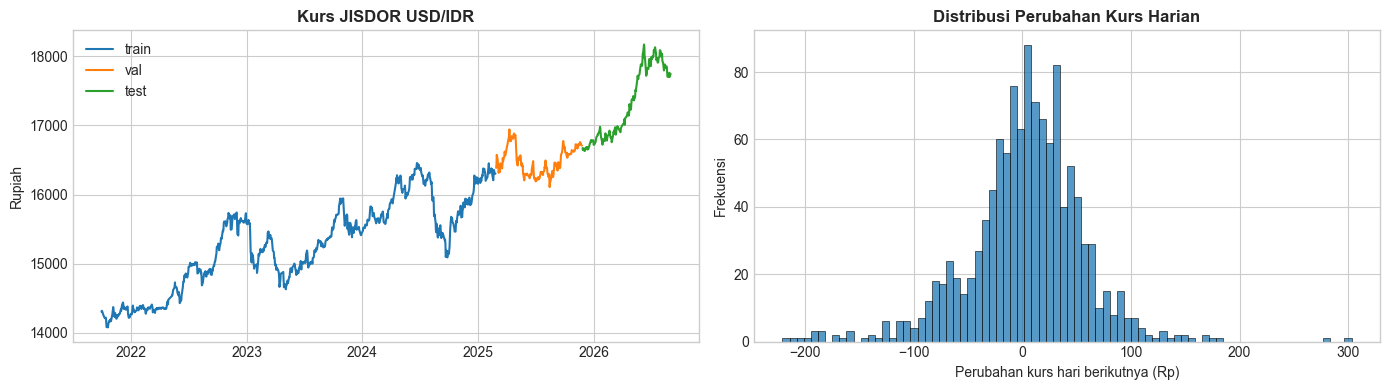

Median besar perubahan harian  : Rp29
Hari dengan perubahan <= Rp10  : 19.5%


In [16]:
sp = pd.concat([pd.read_csv(DATA / f"{s}.csv", parse_dates=["date"]).assign(split=s) for s in ["train", "val", "test"]],
               ignore_index=True)
delta = sp["usd_idr"] * np.expm1(sp["target_ret"])  # perubahan kurs hari berikutnya dalam Rupiah

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, part in sp.groupby("split", sort=False):
    axes[0].plot(part["date"], part["usd_idr"], label=name)
axes[0].set_title("Kurs JISDOR USD/IDR", fontweight="bold")
axes[0].set_ylabel("Rupiah")
axes[0].legend()
sns.histplot(delta, bins=80, ax=axes[1], color="#1f77b4")
axes[1].set_title("Distribusi Perubahan Kurs Harian", fontweight="bold")
axes[1].set_xlabel("Perubahan kurs hari berikutnya (Rp)")
axes[1].set_ylabel("Frekuensi")
plt.tight_layout()
plt.show()

print(f"Median besar perubahan harian  : Rp{delta.abs().median():.0f}")
print(f"Hari dengan perubahan <= Rp10  : {(delta.abs() <= 10).mean():.1%}")

Kurs cenderung naik (rupiah melemah) dari sekitar Rp14.300 menjadi di atas Rp17.500 pada periode test.
Separuh hari perdagangan hanya mengalami perubahan sekitar Rp29 atau kurang, dan 19,5% hari berubah Rp10 atau kurang.
Pada hari dengan perubahan sekecil ini, arah kenaikan atau penurunan kurs cenderung acak sehingga sulit diprediksi.

## 5. Distribusi Kelas NAIK dan TURUN

In [17]:
sp.groupby("split", sort=False)["target"].agg(proporsi_NAIK="mean", jumlah_hari="size").round(3)

,proporsi_NAIK,jumlah_hari
split,,
train,0.558,825
val,0.517,176
test,0.579,178


Kelas NAIK sedikit lebih banyak dan proporsinya berubah antarperiode. Prediksi "selalu NAIK" sudah dapat mencapai
akurasi 52 sampai 58%, sehingga selain akurasi digunakan juga F1-macro dan MCC yang memberi bobot seimbang pada kedua kelas.

## 6. Autokorelasi Perubahan Kurs (Train)
Autokorelasi mengukur keterkaitan perubahan kurs hari ini dengan perubahan pada hari-hari sebelumnya.
Batang yang melewati area abu-abu menunjukkan hubungan yang signifikan.

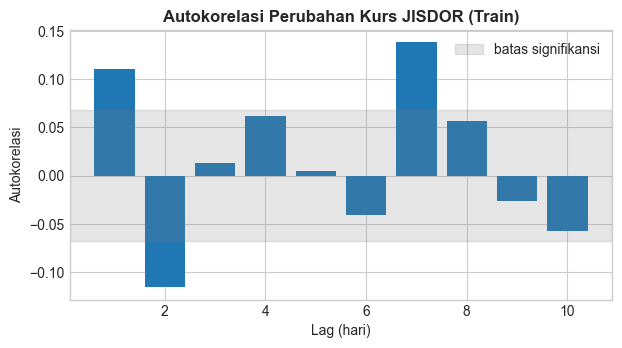

Autokorelasi lag 1-3: [ 0.11  -0.116  0.013]


In [18]:
r = sp.loc[sp.split == "train", "ret_1"]
acf = [r.autocorr(k) for k in range(1, 11)]
batas = 1.96 / np.sqrt(len(r))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(range(1, 11), acf, color="#1f77b4")
ax.axhspan(-batas, batas, color="gray", alpha=0.2, label="batas signifikansi")
ax.set_title("Autokorelasi Perubahan Kurs JISDOR (Train)", fontweight="bold")
ax.set_xlabel("Lag (hari)")
ax.set_ylabel("Autokorelasi")
ax.legend()
plt.show()
print("Autokorelasi lag 1-3:", np.round(acf[:3], 3))

Perubahan kurs hari ini cenderung searah dengan perubahan kemarin (autokorelasi lag-1 positif). Hal ini wajar karena
kurs JISDOR merupakan rata-rata tertimbang transaksi sepanjang hari. Oleh karena itu, baseline persistence
dan model ARIMA penting digunakan sebagai pembanding.

## 7. Panjang Teks Berita per Hari
Panjang teks dihitung dalam jumlah kata untuk gabungan judul, paragraf awal (lead), dan isi lengkap setiap hari.

In [19]:
for col, name in [("judul_gabungan", "title"), ("lead_paragraph_gabungan", "lead"), ("konten_gabungan", "content")]:
    df[f"{name}_word_count"] = df[col].fillna("").apply(lambda x: len(x.split()))

df[["usd_idr", "jumlah_berita", "title_word_count", "lead_word_count", "content_word_count"]].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
usd_idr,1202.0,15742.0,976.1,14080.0,14984.0,15650.5,16384.8,18171.0
jumlah_berita,1202.0,12.0,8.1,0.0,8.0,11.0,14.0,100.0
title_word_count,1202.0,171.8,120.1,0.0,109.0,151.0,204.0,1490.0
lead_word_count,1202.0,876.0,640.0,0.0,531.0,728.5,1009.8,2999.0
content_word_count,1202.0,8425.0,5864.3,0.0,5177.2,7424.0,10198.8,71278.0


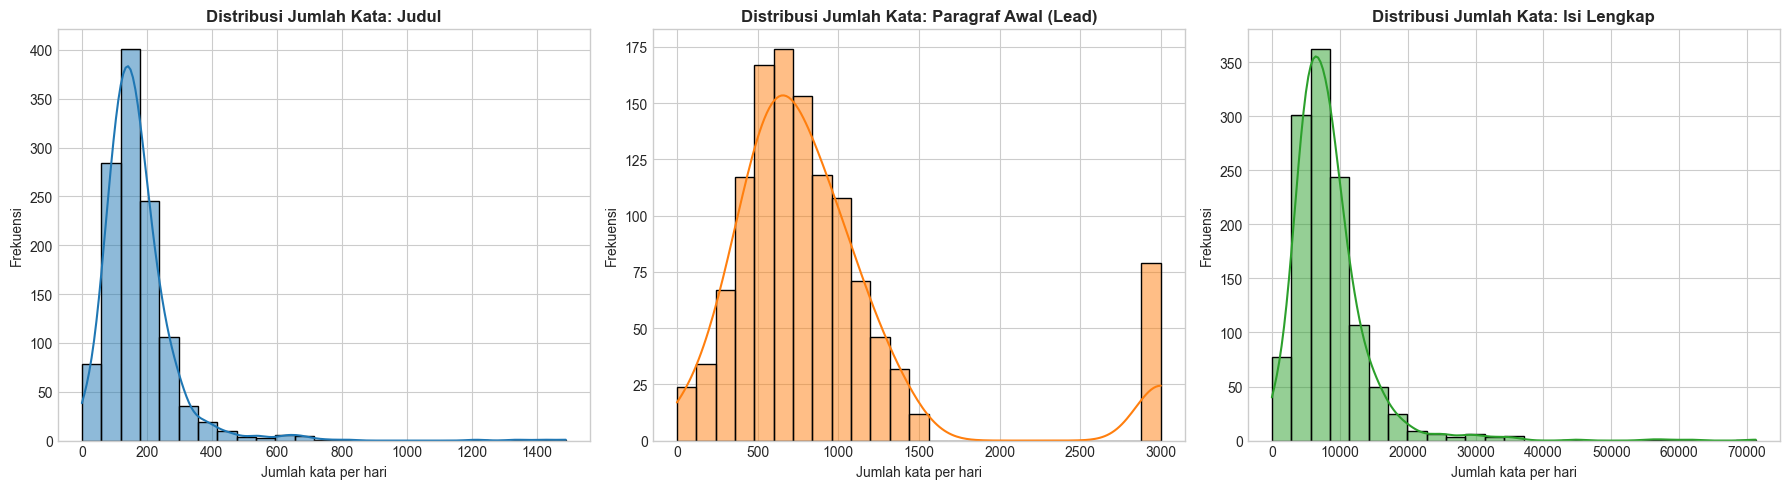

Hari dengan lead >= 2.900 kata : 79
Jumlah berita pada hari tsb.   : minimal 20, median 28


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, title, color) in zip(axes, [("title_word_count", "Judul", "#1f77b4"),
                                          ("lead_word_count", "Paragraf Awal (Lead)", "#ff7f0e"),
                                          ("content_word_count", "Isi Lengkap", "#2ca02c")]):
    sns.histplot(df[col], kde=True, ax=ax, color=color, bins=25)
    ax.set_title(f"Distribusi Jumlah Kata: {title}", fontweight="bold")
    ax.set_xlabel("Jumlah kata per hari")
    ax.set_ylabel("Frekuensi")
plt.tight_layout()
plt.show()

# Memeriksa lonjakan panjang lead di sekitar 3.000 kata
lonjakan = df[df["lead_word_count"] >= 2900]
print(f"Hari dengan lead >= 2.900 kata : {len(lonjakan)}")
print(f"Jumlah berita pada hari tsb.   : minimal {lonjakan['jumlah_berita'].min()}, median {lonjakan['jumlah_berita'].median():.0f}")

Rata-rata terdapat 12 berita per hari. Ketiga distribusi menceng ke kanan: sebagian besar hari memiliki teks
dengan panjang sedang, sedangkan sebagian kecil hari memiliki teks yang sangat panjang.

Pada distribusi lead terdapat lonjakan di sekitar 3.000 kata. Lonjakan ini terjadi pada hari dengan 20 berita atau lebih,
karena gabungan paragraf awalnya terpotong di sekitar 3.000 kata. Oleh karena itu, fitur NLP dihitung per artikel
(folder `data/articles/`), bukan dari kolom gabungan.

## 8. Kata dan Frasa yang Paling Sering Muncul pada Judul

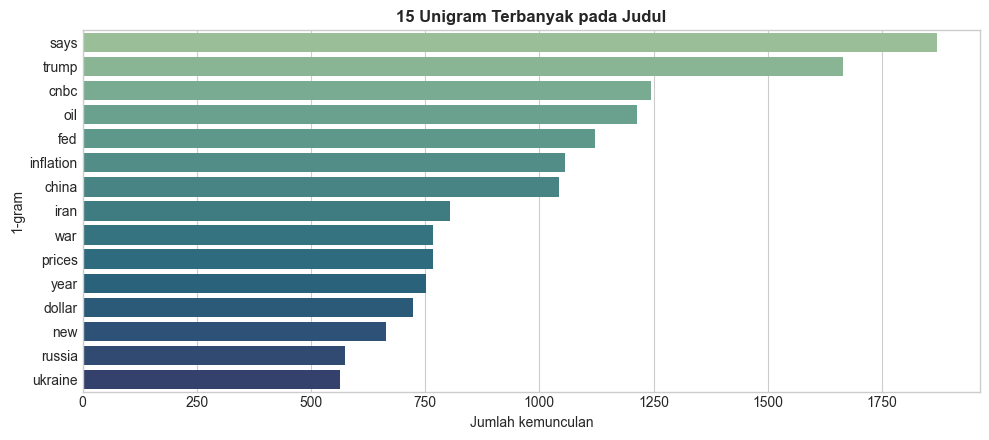

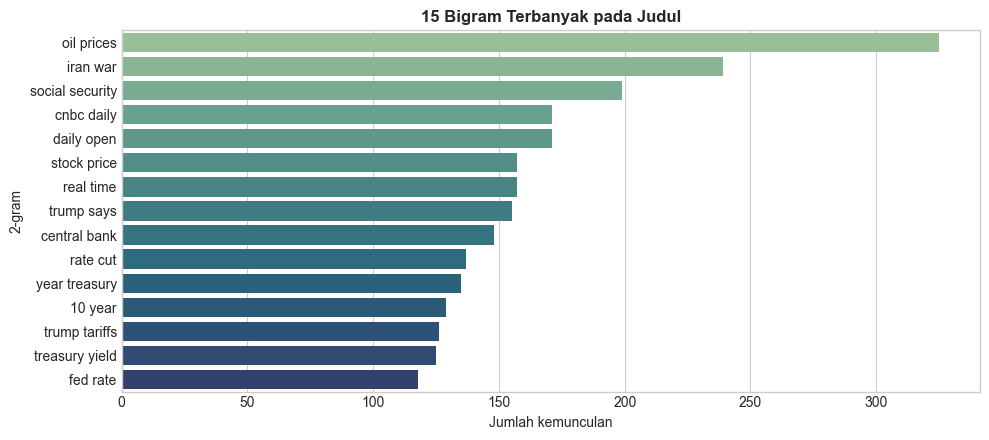

In [21]:
stop_words = list(ENGLISH_STOP_WORDS)


def plot_top_ngrams(text_series, title, n=1, top_k=15):
    """Menampilkan n-gram yang paling sering muncul."""
    cleaned = text_series.fillna("").str.replace("|", " ", regex=False)  # hapus pemisah antarberita
    vec = CountVectorizer(ngram_range=(n, n), stop_words=stop_words)
    counts = vec.fit_transform(cleaned).sum(axis=0)
    freq = sorted(((w, counts[0, i]) for w, i in vec.vocabulary_.items()), key=lambda x: x[1], reverse=True)[:top_k]
    plot_df = pd.DataFrame(freq, columns=["token", "frequency"])

    plt.figure(figsize=(10, 4.5))
    sns.barplot(x="frequency", y="token", data=plot_df, hue="token", palette="crest", legend=False)
    plt.title(title, fontweight="bold")
    plt.xlabel("Jumlah kemunculan")
    plt.ylabel(f"{n}-gram")
    plt.tight_layout()
    plt.show()


plot_top_ngrams(df["judul_gabungan"], "15 Unigram Terbanyak pada Judul", n=1)
plot_top_ngrams(df["judul_gabungan"], "15 Bigram Terbanyak pada Judul", n=2)

Kata yang paling sering muncul umumnya berkaitan dengan kurs, seperti "oil", "fed", "inflation", "china",
"iran war", "central bank", "rate cut", dan "fed rate". Namun, terdapat juga frasa yang tidak berkaitan dengan geopolitik,
seperti "social security", "cnbc daily", dan "stock price real time".

## 9. Relevansi Berita terhadap Kurs
Sebuah artikel dianggap relevan apabila paragraf awalnya memuat minimal satu kata yang berkaitan dengan kurs,
misalnya "war", "sanctions", "fed", "tariff", "oil", "asia", atau "dollar".

In [22]:
art = pd.concat([pd.read_csv(f, usecols=["date", "title", "lead"]) for f in sorted((DATA / "articles").glob("*.csv"))])
art = art.fillna("").sort_values("date", kind="stable").reset_index(drop=True)
kata_kurs = set("war military invasion missile sanctions conflict tensions attack nuclear ceasefire peace talks "
                "fed rates inflation hike cut tightening easing tariff tariffs trade export oil crude opec "
                "indonesia rupiah asia asian emerging dollar greenback currency currencies forex yuan treasury yields".split())
relevan = art["lead"].str.lower().str.findall(r"[a-z]+").map(lambda t: bool(kata_kurs.intersection(t)))

print(f"Artikel yang relevan dengan kurs: {relevan.mean():.1%} dari {len(art)} artikel")
print("Contoh judul artikel yang tidak relevan:")
for t in art.loc[~relevan, "title"].sample(5, random_state=1):
    print(" -", t)

Artikel yang relevan dengan kurs: 61.8% dari 14213 artikel
Contoh judul artikel yang tidak relevan:
 - Berkshire Hathaway’s annual meeting is here: What to expect from Warren Buffett and Charlie Munger
 - Biden hopes fines on lingering cargo containers ease congestion at major U.S. ports
 - India kicks off vote counting for the world’s biggest election, with exit polls projecting a Modi victory
 - China urges calm after U.S. shoots down suspected spy balloon
 - Why energy could be a great place to invest even with oil prices retreating — 5 stocks to buy


Sekitar 38% artikel tidak memuat kata yang berkaitan dengan kurs. Temuan ini sejalan dengan bagian 8: sebagian artikel
memang bukan berita geopolitik, sedangkan sebagian lainnya relevan tetapi tidak tertangkap oleh daftar kata yang digunakan.

## 10. Skor Sentimen VADER dan Loughran-McDonald dari Waktu ke Waktu
Grafik berikut menampilkan rata-rata bulanan skor sentimen pada isi lengkap berita.

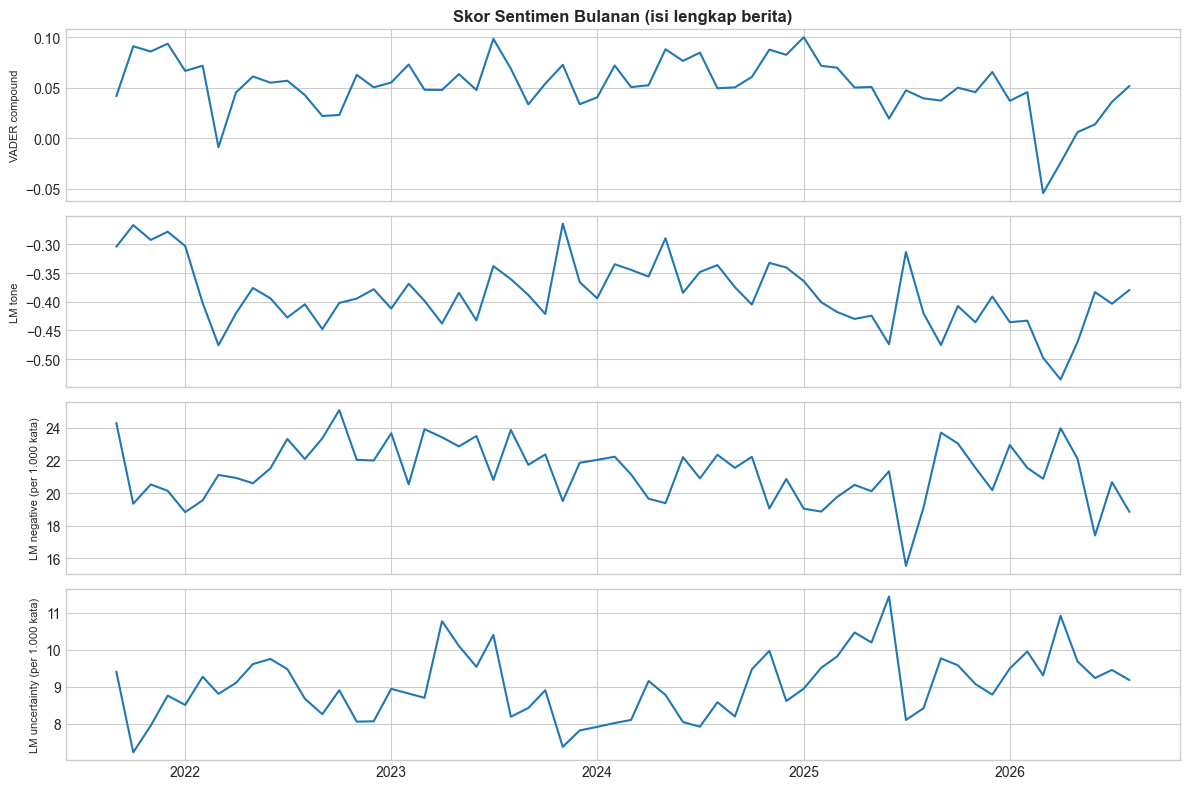

Korelasi bulanan VADER compound dan LM tone: 0.719
VADER compound                   terendah: Mar 2026 | tertinggi: Jan 2025
LM tone                          terendah: Apr 2026 | tertinggi: Nov 2023
LM negative (per 1.000 kata)     terendah: Jul 2025 | tertinggi: Oct 2022
LM uncertainty (per 1.000 kata)  terendah: Oct 2021 | tertinggi: Jun 2025


In [23]:
feat = pd.read_csv(DATA / "features.csv", parse_dates=["date"])
monthly = feat.set_index("date").resample("MS").mean().loc[:"2026-08-01"]

PANEL = [("lex_full_vader_compound", "VADER compound"), ("lex_full_lm_tone", "LM tone"),
         ("lex_full_lm_negative", "LM negative (per 1.000 kata)"), ("lex_full_lm_uncertainty", "LM uncertainty (per 1.000 kata)")]
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
for ax, (col, label) in zip(axes, PANEL):
    ax.plot(monthly.index, monthly[col], color="#1f77b4")
    ax.set_ylabel(label, fontsize=8)
axes[0].set_title("Skor Sentimen Bulanan (isi lengkap berita)", fontweight="bold")
plt.tight_layout()
plt.show()

print("Korelasi bulanan VADER compound dan LM tone:", round(monthly["lex_full_vader_compound"].corr(monthly["lex_full_lm_tone"]), 3))
for col, label in PANEL:
    print(f"{label:32s} terendah: {monthly[col].idxmin():%b %Y} | tertinggi: {monthly[col].idxmax():%b %Y}")

Kedua leksikon bergerak searah (korelasi bulanan 0,719), sehingga keduanya menangkap perubahan nada pemberitaan
yang sama. Nilai LM tone cenderung negatif karena daftar kata negatif Loughran-McDonald jauh lebih banyak
daripada daftar kata positifnya. Beberapa pola sesuai dengan peristiwa besar:
- VADER compound dan LM tone turun tajam pada Maret 2022, bertepatan dengan invasi Rusia ke Ukraina.
- LM uncertainty meningkat sepanjang paruh pertama 2025, bertepatan dengan periode kebijakan tarif Amerika Serikat.
- Nada paling negatif pada kedua leksikon terjadi pada Maret sampai April 2026.

## 11. Hubungan Skor Sentimen dengan Arah Kurs (Train)
Hari-hari pada data train dibagi menjadi lima kelompok sama besar (kuintil) berdasarkan skor sentimen,
dari Q1 (paling negatif) sampai Q5 (paling positif). Untuk setiap kelompok dihitung peluang kurs naik
pada hari berikutnya.

In [24]:
train = sp[sp.split == "train"].merge(feat, on="date")
LABEL_Q = ["Q1 (paling negatif)", "Q2", "Q3", "Q4", "Q5 (paling positif)"]
tabel = {}
for col, nama in [("lex_full_vader_compound", "VADER compound"), ("lex_full_lm_tone", "LM tone")]:
    kuintil = pd.qcut(train[col], 5, labels=LABEL_Q)
    tabel[nama] = train.groupby(kuintil, observed=True)["target"].mean()
tabel = pd.DataFrame(tabel).round(3)
tabel.index.name = "kuintil sentimen"
tabel

,VADER compound,LM tone
kuintil sentimen,,
Q1 (paling negatif),0.539,0.570
Q2,0.624,0.527
Q3,0.552,0.606
Q4,0.564,0.582
Q5 (paling positif),0.509,0.503


Tidak terlihat pola yang searah. Peluang kurs naik tidak meningkat atau menurun secara konsisten dari Q1 ke Q5,
dan kelompok paling positif (Q5) justru memiliki peluang naik terendah (sekitar 50%). Artinya, nada berita
secara umum belum menunjukkan hubungan yang jelas dengan arah kurs hari berikutnya.

## Ringkasan EDA
- Data lengkap dan bersih: 1.202 hari perdagangan, tidak ada tanggal ganda, dan hanya 17 hari tanpa berita.
- Banyak hari dengan perubahan kurs yang sangat kecil, sehingga arahnya sulit diprediksi.
- Kelas NAIK lebih banyak, sehingga selain akurasi digunakan juga F1-macro dan MCC.
- Perubahan kurs memiliki autokorelasi lag-1, sehingga baseline persistence dan ARIMA perlu dijadikan pembanding.
- Gabungan lead terpotong di sekitar 3.000 kata pada hari dengan banyak berita, sehingga fitur NLP dihitung per artikel.
- Judul berita didominasi topik minyak, suku bunga, inflasi, Tiongkok, dan perang Iran, tetapi sekitar 38% artikel
  tidak berkaitan dengan kurs.
- VADER dan Loughran-McDonald menangkap perubahan nada pemberitaan saat peristiwa besar, tetapi hubungan skor
  sentimen dengan arah kurs hari berikutnya lemah, sehingga akurasi yang realistis berada di kisaran 50 sampai 56%.